Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics

Data Collection & Analysis

In [2]:
# loading the data from csv file to a Pandas DataFrame
# (make sure insurance.csv is in the same folder as this notebook)
insurance_dataset = pd.read_csv('insurance.csv')

In [3]:
# first 5 rows of the dataframe
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

In [5]:
# getting some informations about the dataset
insurance_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Categorical Features:
- Sex
- Smoker
- Region

In [6]:
# checking for missing values
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data Analysis

In [7]:
# statistical Measures of the dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_482/3634923312.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['age'])


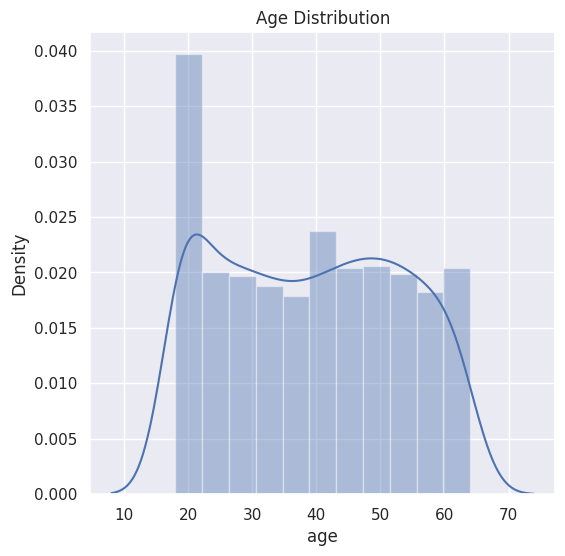

In [8]:
# distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['age'])
plt.title('Age Distribution')
plt.show()

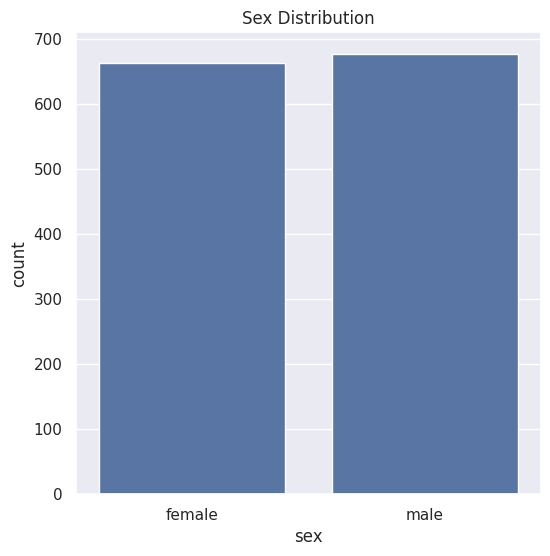

In [9]:
# Gender column
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=insurance_dataset)
plt.title('Sex Distribution')
plt.show()

In [10]:
insurance_dataset['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

/tmp/ipykernel_482/1916795400.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['bmi'])


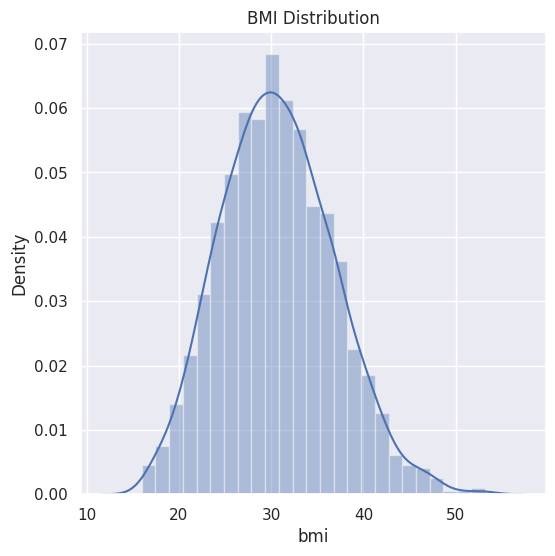

In [11]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['bmi'])
plt.title('BMI Distribution')
plt.show()

Normal BMI Range --> 18.5 to 24.9

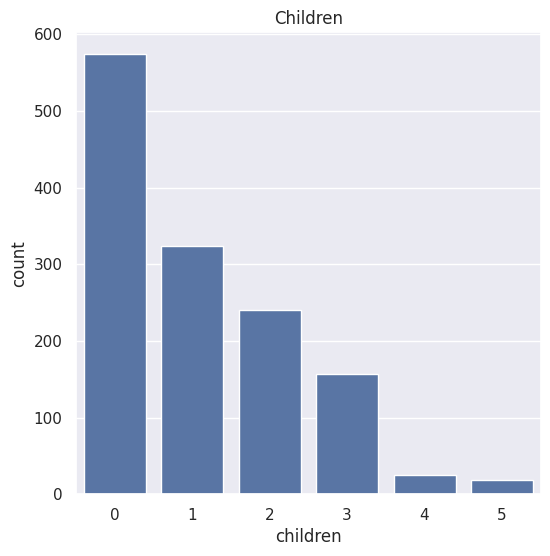

In [12]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=insurance_dataset)
plt.title('Children')
plt.show()

In [13]:
insurance_dataset['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

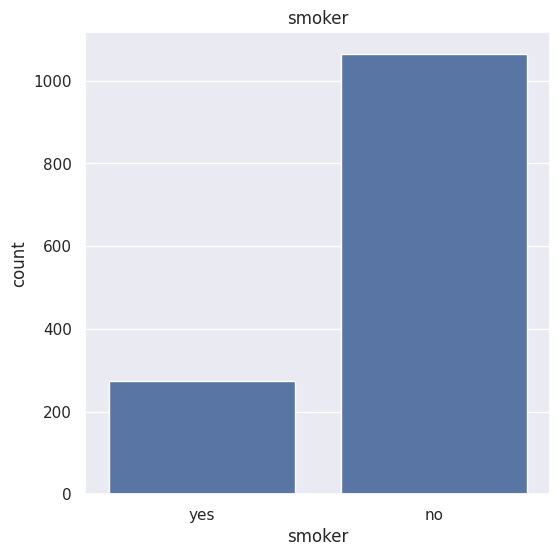

In [14]:
# smoker column
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data=insurance_dataset)
plt.title('smoker')
plt.show()

In [15]:
insurance_dataset['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

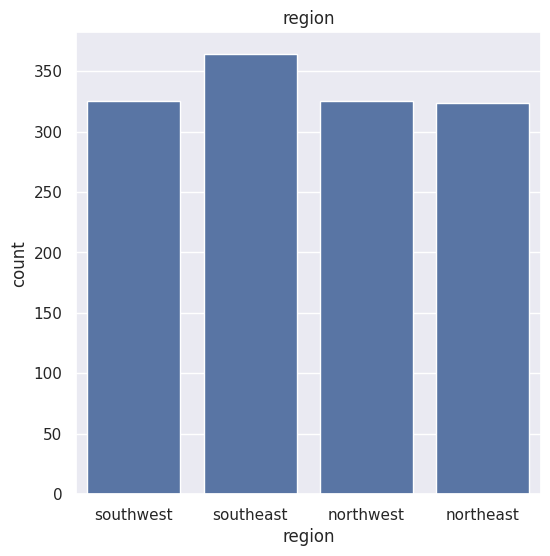

In [16]:
# region column
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=insurance_dataset)
plt.title('region')
plt.show()

In [17]:
insurance_dataset['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

/tmp/ipykernel_482/3971177022.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['charges'])


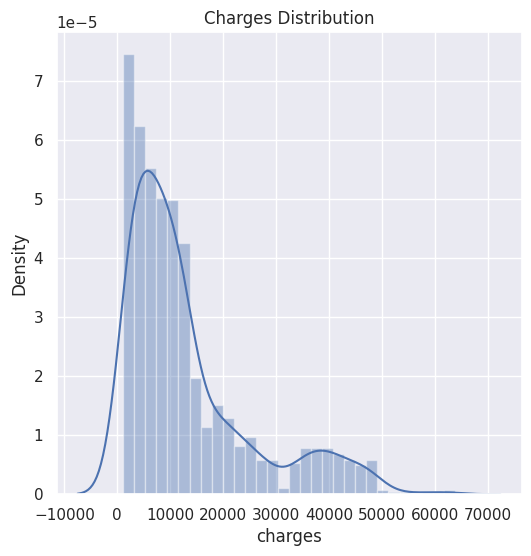

In [18]:
# distribution of charges value
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['charges'])
plt.title('Charges Distribution')
plt.show()

Data Pre-Processing

Encoding the categorical features

In [19]:
# encoding sex column
insurance_dataset.replace({'sex': {'male': 0, 'female': 1}}, inplace=True)

# encoding 'smoker' column
insurance_dataset.replace({'smoker': {'yes': 0, 'no': 1}}, inplace=True)

# encoding 'region' column
insurance_dataset.replace({'region': {'southeast': 0, 'southwest': 1, 'northeast': 2, 'northwest': 3}}, inplace=True)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,3,10600.54830
1334,18,1,31.920,0,1,2,2205.98080
1335,18,1,36.850,0,1,0,1629.83350
1336,21,1,25.800,0,1,1,2007.94500


Splitting the Features and Target

In [20]:
X = insurance_dataset.drop(columns='charges')
Y = insurance_dataset['charges']

In [21]:
print(X)

      age sex     bmi  children smoker region
0      19   1  27.900         0      0      1
1      18   0  33.770         1      1      0
2      28   0  33.000         3      1      0
3      33   0  22.705         0      1      3
4      32   0  28.880         0      1      3
...   ...  ..     ...       ...    ...    ...
1333   50   0  30.970         3      1      3
1334   18   1  31.920         0      1      2
1335   18   1  36.850         0      1      0
1336   21   1  25.800         0      1      1
1337   61   1  29.070         0      0      3

[1338 rows x 6 columns]


In [22]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


Splitting the data into Training data & Testing Data

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

### Feature Scaling
Ridge and Lasso apply a penalty based on the *size* of each coefficient. If one feature (like `bmi`, roughly 15-53) is on a totally different scale than another (like `smoker`, which is just 0 or 1), the penalty ends up affecting them unfairly - features with naturally larger values get penalized more, just because of their scale, not because they're actually less important.

Scaling every feature to the same range (mean = 0, std = 1) fixes this, so Ridge and Lasso can compare features fairly. We fit the scaler only on training data and use it to transform both train and test data, so no information from the test set leaks into training.

Note: Linear Regression, Random Forest and Gradient Boosting don't need this - Linear Regression's R2 isn't affected by scaling, and tree-based models split on raw feature values so scale doesn't matter to them.

In [24]:
# creating a scaled version of our features, to be used only for Ridge and Lasso
scaler = StandardScaler()

# fit_transform on training data: learns the mean/std AND scales it
X_train_scaled = scaler.fit_transform(X_train)

# transform only (no fit) on test data: reuses the mean/std learned from training data
X_test_scaled = scaler.transform(X_test)

In [25]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


Model Training

Linear Regression

In [26]:
# loading the Linear Regression model
regressor = LinearRegression()

In [27]:
regressor.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model Evaluation

In [28]:
# prediction on training data
training_data_prediction =regressor.predict(X_train)

In [29]:
# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R squared vale : ', r2_train)

R squared vale :  0.751505643411174


In [30]:
# prediction on test data
test_data_prediction =regressor.predict(X_test)

In [31]:
# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R squared vale : ', r2_test)

R squared vale :  0.7447273869684077


In [32]:
# let's also check RMSE and MAE, not just R squared
# RMSE (Root Mean Squared Error) tells us the average prediction error in the same units as charges
# MAE (Mean Absolute Error) is another simple way to see how far off our predictions are, on average

linear_train_rmse = np.sqrt(metrics.mean_squared_error(Y_train, training_data_prediction))
linear_train_mae = metrics.mean_absolute_error(Y_train, training_data_prediction)

linear_test_rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_data_prediction))
linear_test_mae = metrics.mean_absolute_error(Y_test, test_data_prediction)

print('Linear Regression - Training Data')
print('RMSE : ', linear_train_rmse)
print('MAE  : ', linear_train_mae)
print('R2   : ', r2_train)

print()
print('Linear Regression - Test Data')
print('RMSE : ', linear_test_rmse)
print('MAE  : ', linear_test_mae)
print('R2   : ', r2_test)

Linear Regression - Training Data
RMSE :  6014.563860089281
MAE  :  4150.500304883776
R2   :  0.751505643411174

Linear Regression - Test Data
RMSE :  6191.690842285234
MAE  :  4267.213826730733
R2   :  0.7447273869684077


## Trying Out More Models
Linear Regression gives us a decent baseline, but let's see if Ridge, Lasso, Random Forest and Gradient Boosting can do a better job of predicting the charges. For every model we'll look at 3 metrics on both training and test data:

- **RMSE** (Root Mean Squared Error) — average error, penalizes big mistakes more
- **MAE** (Mean Absolute Error) — average error, treats all mistakes equally
- **R² Score** — how much of the variation in charges our model is able to explain (closer to 1 is better)

A quick helper function so we don't have to repeat the same code for every model:

In [33]:
# this function takes a trained model and prints RMSE, MAE and R2 for both train and test data
# saves us from copy-pasting the same 6 lines again and again for every model

def evaluate_model(model_name, model, X_train, X_test, Y_train, Y_test):
    # predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # training metrics
    train_rmse = np.sqrt(metrics.mean_squared_error(Y_train, train_pred))
    train_mae = metrics.mean_absolute_error(Y_train, train_pred)
    train_r2 = metrics.r2_score(Y_train, train_pred)

    # test metrics
    test_rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_pred))
    test_mae = metrics.mean_absolute_error(Y_test, test_pred)
    test_r2 = metrics.r2_score(Y_test, test_pred)

    print(f'--- {model_name} ---')
    print('Training Data -> RMSE: {:.2f} | MAE: {:.2f} | R2: {:.4f}'.format(train_rmse, train_mae, train_r2))
    print('Test Data     -> RMSE: {:.2f} | MAE: {:.2f} | R2: {:.4f}'.format(test_rmse, test_mae, test_r2))
    print()

    # returning everything so we can build a comparison table later
    return {
        'Model': model_name,
        'Train RMSE': train_rmse, 'Train MAE': train_mae, 'Train R2': train_r2,
        'Test RMSE': test_rmse, 'Test MAE': test_mae, 'Test R2': test_r2
    }

In [34]:
# an empty list where we'll collect the results of every model, one dictionary at a time
results = []

# adding the Linear Regression results we already calculated above, so it shows up in the comparison too
results.append({
    'Model': 'Linear Regression',
    'Train RMSE': linear_train_rmse, 'Train MAE': linear_train_mae, 'Train R2': r2_train,
    'Test RMSE': linear_test_rmse, 'Test MAE': linear_test_mae, 'Test R2': r2_test
})

### Ridge Regression
Ridge is basically Linear Regression with a penalty added on large coefficients (this is called L2 regularization). It helps the model avoid overfitting when features are correlated with each other.

We use the **scaled** features here (`X_train_scaled` / `X_test_scaled`) since Ridge is sensitive to feature scale.

In [35]:
# loading and training the Ridge Regression model
# alpha controls how strong the penalty is - higher alpha means more regularization
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, Y_train)

results.append(evaluate_model('Ridge Regression', ridge_model, X_train_scaled, X_test_scaled, Y_train, Y_test))

--- Ridge Regression ---
Training Data -> RMSE: 6014.57 | MAE: 4151.97 | R2: 0.7515
Test Data     -> RMSE: 6191.73 | MAE: 4267.71 | R2: 0.7447



### Lasso Regression
Lasso is similar to Ridge, but it uses L1 regularization instead. One nice side effect of Lasso is that it can shrink less useful feature coefficients all the way down to zero, which works like automatic feature selection.

Just like Ridge, we use the **scaled** features here so the penalty treats every feature fairly.

In [36]:
# loading and training the Lasso Regression model
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, Y_train)

results.append(evaluate_model('Lasso Regression', lasso_model, X_train_scaled, X_test_scaled, Y_train, Y_test))

--- Lasso Regression ---
Training Data -> RMSE: 6014.56 | MAE: 4150.49 | R2: 0.7515
Test Data     -> RMSE: 6191.79 | MAE: 4266.81 | R2: 0.7447



### Random Forest Regressor
Random Forest builds a bunch of decision trees on random subsets of the data and features, then averages their predictions. It can capture non-linear relationships that a plain linear model would miss.

In [37]:
# loading and training the Random Forest model
# n_estimators is the number of trees in the forest, random_state just makes results reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=2)
rf_model.fit(X_train, Y_train)

results.append(evaluate_model('Random Forest', rf_model, X_train, X_test, Y_train, Y_test))

--- Random Forest ---
Training Data -> RMSE: 1817.72 | MAE: 1016.64 | R2: 0.9773
Test Data     -> RMSE: 4947.95 | MAE: 2795.39 | R2: 0.8370



### Gradient Boosting Regressor
Gradient Boosting also builds a bunch of trees, but instead of building them independently like Random Forest, it builds them one after another, where each new tree tries to fix the errors made by the previous ones.

In [38]:
# loading and training the Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=2)
gb_model.fit(X_train, Y_train)

results.append(evaluate_model('Gradient Boosting', gb_model, X_train, X_test, Y_train, Y_test))

--- Gradient Boosting ---
Training Data -> RMSE: 3710.53 | MAE: 2029.45 | R2: 0.9054
Test Data     -> RMSE: 4445.41 | MAE: 2376.10 | R2: 0.8684



## Comparing All Models
Now let's put everything side by side in one table so it's easy to see which model actually performs the best on the test data.

In [39]:
# converting our list of dictionaries into a DataFrame so it's easy to read and compare
results_df = pd.DataFrame(results)

# sorting by Test R2 (higher is better) so the best model shows up on top
results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
results_df

,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Gradient Boosting,3710.529653,2029.454265,0.905424,4445.407120,2376.097343,0.868414
1,Random Forest,1817.721038,1016.640190,0.977303,4947.952841,2795.391817,0.836982
2,Linear Regression,6014.563860,4150.500305,0.751506,6191.690842,4267.213827,0.744727
3,Ridge Regression,6014.571970,4151.969901,0.751505,6191.732637,4267.714556,0.744724
4,Lasso Regression,6014.564433,4150.490085,0.751506,6191.786010,4266.805336,0.744720


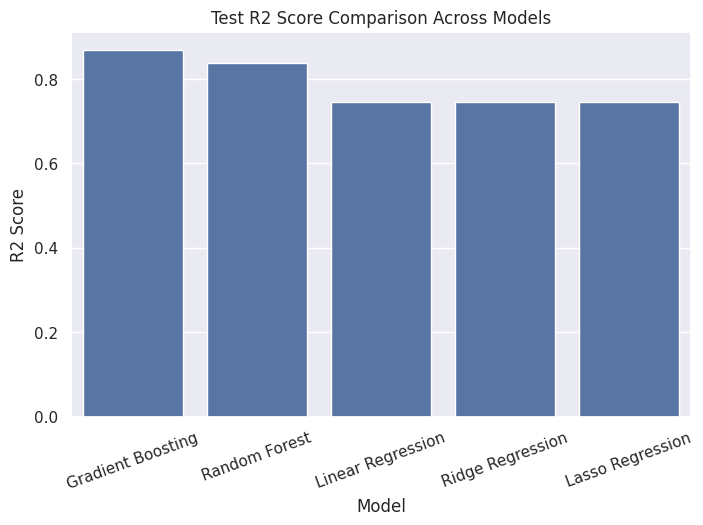

In [40]:
# a simple bar chart to visually compare Test R2 scores of all models
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test R2', data=results_df)
plt.title('Test R2 Score Comparison Across Models')
plt.xticks(rotation=20)
plt.ylabel('R2 Score')
plt.show()

From the table and chart above, the tree-based models (Random Forest and Gradient Boosting) usually end up beating the plain Linear/Ridge/Lasso models on this dataset, because charges don't increase in a simple straight-line way with age, bmi, and smoking status — there are non-linear patterns (like smokers with high bmi having a much higher jump in charges) that tree-based models are better at capturing.

## Hyperparameter Tuning using Cross-Validation
So far we trained every model with default (or manually picked) settings. Now let's actually search for the best settings (called **hyperparameters**) for each model using **GridSearchCV**.

GridSearchCV basically tries out every combination of hyperparameters we give it, and for each combination it does **k-fold cross-validation** — meaning it splits the training data into k parts (we'll use 5), trains on k-1 parts and validates on the remaining part, and repeats this k times. This gives a much more reliable estimate of how good a hyperparameter combination is, compared to checking performance on just one split.

At the end, it tells us the best combination it found, and we can use that to build our final, tuned model.

### Tuning Ridge Regression
**Important note on scaling + cross-validation:** earlier we scaled `X_train` once, before doing cross-validation. But that means the scaler's mean/std were calculated using the *entire* `X_train` - including the part that ends up being the "unseen" validation fold inside each CV split. That's a small form of **data leakage**: information from the validation fold quietly leaks into the scaling step.

The correct fix is to use a **Pipeline** that bundles the scaler and the model together. When GridSearchCV runs cross-validation on a pipeline, it fits the scaler fresh on only that fold's training portion each time, and never touches that fold's validation portion. So from here on, we pass the **raw, unscaled** `X_train` / `X_test` into the pipeline, and let the pipeline handle scaling internally, fold by fold.

In [41]:
# bundling the scaler + Ridge model together so scaling happens fresh inside every CV fold
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# note the 'ridge__' prefix - it tells GridSearchCV which step in the pipeline this param belongs to
ridge_param_grid = {'ridge__alpha': [0.01, 0.1, 1, 10, 50, 100]}

ridge_grid_search = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring='r2', n_jobs=-1)

# passing raw, unscaled X_train here - the pipeline takes care of scaling on its own
ridge_grid_search.fit(X_train, Y_train)

print('Best alpha for Ridge : ', ridge_grid_search.best_params_)
print('Best CV R2 score     : ', ridge_grid_search.best_score_)

# best_estimator_ here is the whole pipeline (scaler + model), so we can predict directly on raw data
ridge_best_model = ridge_grid_search.best_estimator_
results.append(evaluate_model('Ridge (Tuned)', ridge_best_model, X_train, X_test, Y_train, Y_test))

Best alpha for Ridge :  {'ridge__alpha': 10}
Best CV R2 score     :  0.735999481961229
--- Ridge (Tuned) ---
Training Data -> RMSE: 6015.36 | MAE: 4165.29 | R2: 0.7514
Test Data     -> RMSE: 6192.81 | MAE: 4272.24 | R2: 0.7446



### Tuning Lasso Regression
Same Pipeline approach here, for the same reason.

In [42]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

lasso_param_grid = {'lasso__alpha': [0.01, 0.1, 1, 10, 50, 100]}

lasso_grid_search = GridSearchCV(lasso_pipeline, lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train, Y_train)

print('Best alpha for Lasso : ', lasso_grid_search.best_params_)
print('Best CV R2 score     : ', lasso_grid_search.best_score_)

lasso_best_model = lasso_grid_search.best_estimator_
results.append(evaluate_model('Lasso (Tuned)', lasso_best_model, X_train, X_test, Y_train, Y_test))

Best alpha for Lasso :  {'lasso__alpha': 50}
Best CV R2 score     :  0.7358614569353115
--- Lasso (Tuned) ---
Training Data -> RMSE: 6015.72 | MAE: 4150.21 | R2: 0.7514
Test Data     -> RMSE: 6195.59 | MAE: 4250.49 | R2: 0.7444



### Tuning Random Forest Regressor
Random Forest has more knobs to tune, so this search takes a little longer than the ones above (GridSearchCV is trying every single combination of the values below, 5 times each for cross-validation).

In [43]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],       # number of trees
    'max_depth': [None, 5, 10, 15],        # how deep each tree can grow
    'min_samples_leaf': [1, 2, 4]          # minimum samples required at a leaf node
}

rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=2),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
rf_grid_search.fit(X_train, Y_train)

print('Best params for Random Forest : ', rf_grid_search.best_params_)
print('Best CV R2 score               : ', rf_grid_search.best_score_)

rf_best_model = rf_grid_search.best_estimator_
results.append(evaluate_model('Random Forest (Tuned)', rf_best_model, X_train, X_test, Y_train, Y_test))

Best params for Random Forest :  {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV R2 score               :  0.8479713657447645
--- Random Forest (Tuned) ---
Training Data -> RMSE: 4089.46 | MAE: 2256.90 | R2: 0.8851
Test Data     -> RMSE: 4419.08 | MAE: 2351.10 | R2: 0.8700



### Tuning Gradient Boosting Regressor

In [44]:
gb_param_grid = {
    'n_estimators': [50, 100, 200],        # number of boosting stages (trees)
    'learning_rate': [0.01, 0.05, 0.1],    # how much each tree contributes to the final prediction
    'max_depth': [2, 3, 4]                  # how deep each individual tree can grow
}

gb_grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=2),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
gb_grid_search.fit(X_train, Y_train)

print('Best params for Gradient Boosting : ', gb_grid_search.best_params_)
print('Best CV R2 score                   : ', gb_grid_search.best_score_)

gb_best_model = gb_grid_search.best_estimator_
results.append(evaluate_model('Gradient Boosting (Tuned)', gb_best_model, X_train, X_test, Y_train, Y_test))

Best params for Gradient Boosting :  {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Best CV R2 score                   :  0.8466953757199136
--- Gradient Boosting (Tuned) ---
Training Data -> RMSE: 4203.98 | MAE: 2322.05 | R2: 0.8786
Test Data     -> RMSE: 4416.72 | MAE: 2418.68 | R2: 0.8701



## Final Comparison — Before vs After Tuning
Let's rebuild our comparison table now that it has both the baseline (default settings) and tuned versions of every model, sorted by Test R2 so the best one is right at the top.

In [45]:
final_results_df = pd.DataFrame(results)
final_results_df = final_results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
final_results_df

,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Gradient Boosting (Tuned),4203.977312,2322.046416,0.878597,4416.724782,2418.682991,0.870107
1,Random Forest (Tuned),4089.463966,2256.903586,0.885121,4419.080987,2351.101057,0.869968
2,Gradient Boosting,3710.529653,2029.454265,0.905424,4445.407120,2376.097343,0.868414
3,Random Forest,1817.721038,1016.640190,0.977303,4947.952841,2795.391817,0.836982
4,Linear Regression,6014.563860,4150.500305,0.751506,6191.690842,4267.213827,0.744727
5,Ridge Regression,6014.571970,4151.969901,0.751505,6191.732637,4267.714556,0.744724
6,Lasso Regression,6014.564433,4150.490085,0.751506,6191.786010,4266.805336,0.744720
7,Ridge (Tuned),6015.360886,4165.288107,0.751440,6192.812442,4272.242454,0.744635
8,Lasso (Tuned),6015.719770,4150.213920,0.751410,6195.588771,4250.490894,0.744406


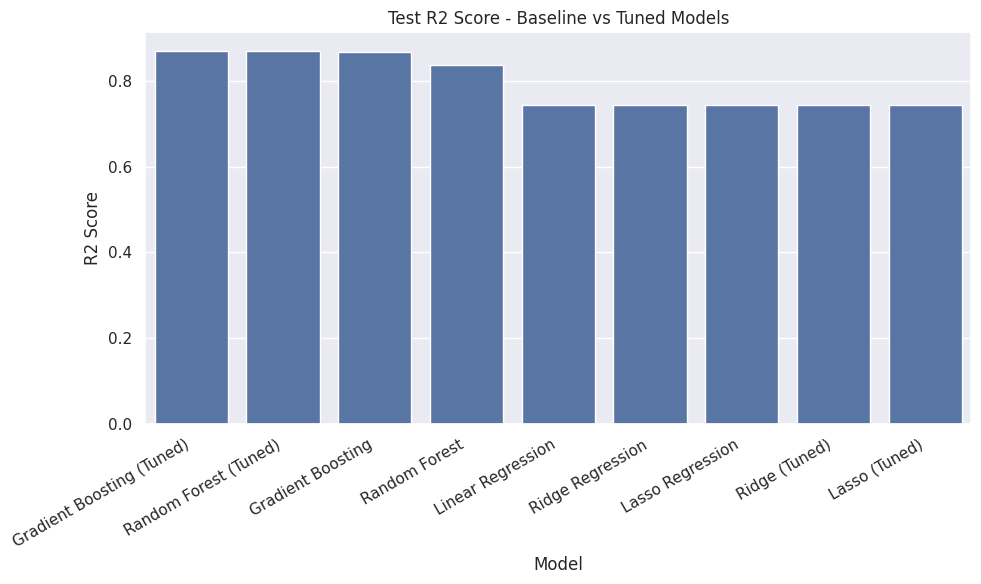

In [46]:
# visualizing all models (baseline + tuned) together
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test R2', data=final_results_df)
plt.title('Test R2 Score - Baseline vs Tuned Models')
plt.xticks(rotation=30, ha='right')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()

Tuning usually gives Ridge and Lasso only a tiny boost since they don't have much to tune, but for Random Forest and Gradient Boosting it can meaningfully improve the test score by finding a better balance between underfitting and overfitting (for example, limiting `max_depth` so the trees don't just memorize the training data).

Building a Predictive System

In [47]:
input_data = (31,1,25.74,0,1,0)

# changing input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)
print(prediction)

print('The insurance cost is USD ', prediction[0])

[3760.0805765]
The insurance cost is USD  3760.080576496055


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
